In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)

In [3]:
train_data = pd.read_parquet("data/train_data_engineered.parquet")
test_data = pd.read_parquet("data/test_data_engineered.parquet")

print(train_data.shape, test_data.shape)
train_data.dtypes

(1296675, 25) (555719, 25)


amt                        float64
gender                       int64
city_pop                     int64
is_fraud                     int64
age                        float64
hour                         int32
day_of_week                  int32
is_night                      bool
category_entertainment       int64
category_food_dining         int64
category_gas_transport       int64
category_grocery_net         int64
category_grocery_pos         int64
category_health_fitness      int64
category_home                int64
category_kids_pets           int64
category_misc_net            int64
category_misc_pos            int64
category_personal_care       int64
category_shopping_net        int64
category_shopping_pos        int64
category_travel              int64
merchant_freq              float64
city_freq                  float64
job_freq                   float64
dtype: object

In [4]:
train_data["is_night"] = train_data["is_night"].astype(int)
test_data["is_night"] = test_data["is_night"].astype(int)

X_train = train_data.drop(columns="is_fraud")
y_train = train_data["is_fraud"]

X_test = test_data.drop(columns="is_fraud")
y_test = test_data["is_fraud"]

print(X_train.shape, X_test.shape)

(1296675, 24) (555719, 24)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=88)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,88
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=["legit", "fraud"]))

              precision    recall  f1-score   support

       legit       1.00      0.88      0.93    553574
       fraud       0.03      0.90      0.05      2145

    accuracy                           0.88    555719
   macro avg       0.51      0.89      0.49    555719
weighted avg       1.00      0.88      0.93    555719



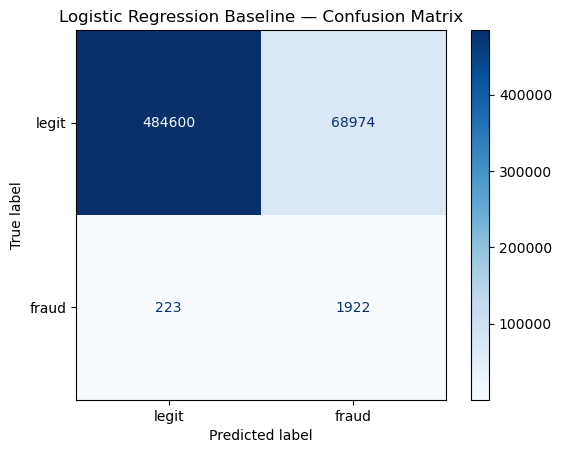

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["legit", "fraud"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Baseline — Confusion Matrix")
plt.show()

In [9]:
pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"PR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

PR-AUC:  0.1811
ROC-AUC: 0.9537
